# Distribution Shift on BirdSet using AudioMAE embeddings

This notebook computes shift metrics between BirdSet subsets using clip-level embeddings produced by the Hugging Face AudioMAE model (see `uncertainbird/scripts/dump_audiomae_embeddings.py`). We report several complementary distances:

- MMD (RBF kernel)
- Fréchet distance (FID-style on Gaussian statistics)
- Energy distance
- Optional: entropic OT (Sinkhorn) on sampled embeddings

You can adjust the subset pairs, split (train or test), and sampling size below.

In [9]:
# Parameters
import os
from pathlib import Path
import glob
import pickle
import math
import numpy as np
import torch

# Base directory where `dump_audiomae_embeddings.py` stored results
OUTPUT_DIR = Path("/workspace/logs/embeddings/")

# Select subset pairs and split to compare
# Example: compare Train vs Test within the same subset or compare two subsets on the same split
PAIRS = [
    ("NBP", "train", "NBP", "test"), 
    ("HSN", "train", "HSN", "test"), 
    ("NES", "train", "NES", "test"), 
    ("SNE", "train", "SNE", "test"), 
    ("SSW", "train", "SSW", "test"), 
    ("UHH", "train", "UHH", "test"), 
    # ("PER", "train", "PER", "test"), 
    # ("POW", "train", "POW", "test"), 
    #  same subset, train vs test
    # ("PER", "train", "NBP", "train"),  # cross-subset, same split
]

# Sampling for scalable metrics
MAX_SAMPLES_PER_DOMAIN = 2000  # clip-level embeddings per domain
RANDOM_SEED = 42

# Enable/disable OT (Sinkhorn) as it can be more expensive
ENABLE_OT = True
SINKHORN_EPS = 0.05  # entropic regularization
SINKHORN_ITERS = 200

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {DEVICE}")

Using cuda


In [10]:
# Helpers: load latest pickle for (subset, split) and sample embeddings

def latest_pickle_for(subset: str, split: str) -> Path | None:
    base = OUTPUT_DIR / subset / split
    if not base.exists():
        return None
    picks = sorted(base.glob("audiomae_embeddings_*.pkl"), key=lambda p: p.stat().st_mtime, reverse=True)
    return picks[0] if picks else None


def load_clip_embeddings(subset: str, split: str) -> torch.Tensor:
    p = latest_pickle_for(subset, split)
    if p is None:
        raise FileNotFoundError(f"No pickle found for {subset}/{split} under {OUTPUT_DIR}")
    with open(p, "rb") as f:
        data = pickle.load(f)
    emb = data["clip_embeddings"]  # Tensor [N, D]
    if not isinstance(emb, torch.Tensor):
        emb = torch.as_tensor(emb)
    return emb


def sample_embeddings(x: torch.Tensor, max_n: int, seed: int = 42) -> torch.Tensor:
    if x.shape[0] <= max_n:
        return x
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(x.shape[0], generator=g)[:max_n]
    return x[idx]

In [7]:
# Metrics: MMD (RBF), Fréchet (FID-style), Energy distance, optional Sinkhorn OT

def pairwise_sq_dists(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    # ||x - y||^2 = ||x||^2 + ||y||^2 - 2 x.y
    x2 = (x * x).sum(dim=1, keepdim=True)
    y2 = (y * y).sum(dim=1, keepdim=True).T
    return x2 + y2 - 2.0 * (x @ y.T)


def rbf_kernel(x: torch.Tensor, y: torch.Tensor, gamma: float) -> torch.Tensor:
    d2 = pairwise_sq_dists(x, y)
    return torch.exp(-gamma * d2)


def median_heuristic_gamma(x: torch.Tensor, y: torch.Tensor) -> float:
    with torch.no_grad():
        # sample a subset for efficiency
        xs = x if x.shape[0] <= 1000 else x[torch.randperm(x.shape[0])[:1000]]
        ys = y if y.shape[0] <= 1000 else y[torch.randperm(y.shape[0])[:1000]]
        d2 = pairwise_sq_dists(xs, ys)
        med = torch.median(d2)
        g = 1.0 / (2.0 * (med.item() + 1e-8))
    return g


def mmd_rbf(x: torch.Tensor, y: torch.Tensor) -> float:
    gamma = median_heuristic_gamma(x, y)
    Kxx = rbf_kernel(x, x, gamma)
    Kyy = rbf_kernel(y, y, gamma)
    Kxy = rbf_kernel(x, y, gamma)
    n = x.shape[0]
    m = y.shape[0]
    # Unbiased MMD^2
    mmd2 = (Kxx.sum() - Kxx.trace()) / (n * (n - 1) + 1e-8)
    mmd2 += (Kyy.sum() - Kyy.trace()) / (m * (m - 1) + 1e-8)
    mmd2 -= 2.0 * Kxy.mean()
    return float(mmd2.item())


def frechet_distance(x: torch.Tensor, y: torch.Tensor) -> float:
    # Compute mean/cov and Fréchet distance
    mu1 = x.mean(dim=0)
    mu2 = y.mean(dim=0)
    x_c = x - mu1
    y_c = y - mu2
    # cov with unbiased=False for stability
    cov1 = (x_c.T @ x_c) / (x.shape[0] - 1)
    cov2 = (y_c.T @ y_c) / (y.shape[0] - 1)
    diff = mu1 - mu2
    eps = 1e-6
    cov1 = cov1 + eps * torch.eye(cov1.shape[0], device=cov1.device)
    cov2 = cov2 + eps * torch.eye(cov2.shape[0], device=cov2.device)
    # eigenvalues of the product are non-negative in theory; clip numerically
    eigvals = torch.linalg.eigvals(cov1 @ cov2).real.clamp(min=0)
    tr_cov1 = torch.trace(cov1)
    tr_cov2 = torch.trace(cov2)
    tr_sqrt = torch.sum(torch.sqrt(eigvals + eps))
    fid = (diff @ diff).item() + (tr_cov1 + tr_cov2 - 2.0 * tr_sqrt).item()
    return float(fid)


def energy_distance(x: torch.Tensor, y: torch.Tensor) -> float:
    # E = 2 E||X - Y|| - E||X - X'|| - E||Y - Y'||
    def mean_pairwise_norm(a, b):
        d2 = pairwise_sq_dists(a, b)
        return torch.mean(torch.sqrt(torch.clamp(d2, min=0)))
    term_xy = mean_pairwise_norm(x, y)
    term_xx = mean_pairwise_norm(x, x)
    term_yy = mean_pairwise_norm(y, y)
    e = 2 * term_xy - term_xx - term_yy
    return float(e.item())


def sinkhorn_ot(x: torch.Tensor, y: torch.Tensor, eps: float = 0.05, iters: int = 200) -> float:
    # Simple entropic OT on uniform measures; returns transport cost
    n, m = x.shape[0], y.shape[0]
    C = pairwise_sq_dists(x, y)  # cost matrix (squared euclidean)
    K = torch.exp(-C / eps)
    u = torch.ones(n, device=x.device) / n
    v = torch.ones(m, device=x.device) / m
    for _ in range(iters):
        u = 1.0 / (K @ v)
        v = 1.0 / (K.T @ u)
    P = torch.diag(u) @ K @ torch.diag(v)
    cost = torch.sum(P * C)
    return float(cost.item())

In [11]:
# Run metrics across selected pairs
import pandas as pd

rows = []
for (a_subset, a_split, b_subset, b_split) in PAIRS:
    xa = load_clip_embeddings(a_subset, a_split)
    xb = load_clip_embeddings(b_subset, b_split)
    # sample and move to device
    xa = sample_embeddings(xa, MAX_SAMPLES_PER_DOMAIN, RANDOM_SEED).to(DEVICE)
    xb = sample_embeddings(xb, MAX_SAMPLES_PER_DOMAIN, RANDOM_SEED + 1).to(DEVICE)
    # center for some metrics stability
    with torch.no_grad():
        # ensure float32
        xa = xa.float()
        xb = xb.float()
    # compute metrics
    mmd = mmd_rbf(xa, xb)
    ed = energy_distance(xa, xb)
    try:
        fid = frechet_distance(xa, xb)
    except Exception:
        fid = float("nan")
    ot = None
    if ENABLE_OT:
        ot = sinkhorn_ot(xa, xb, eps=SINKHORN_EPS, iters=SINKHORN_ITERS)

    row = {
        "A": f"{a_subset}/{a_split}",
        "B": f"{b_subset}/{b_split}",
        "N_A": xa.shape[0],
        "N_B": xb.shape[0],
        "MMD_RBF": mmd,
        "Energy": ed,
        "Frechet": fid,
        "SinkhornOT": ot,
    }
    print(row)
    rows.append(row)

results = pd.DataFrame(rows)
results

{'A': 'NBP/train', 'B': 'NBP/test', 'N_A': 2000, 'N_B': 539, 'MMD_RBF': 0.29257333278656006, 'Energy': 0.17178025841712952, 'Frechet': -1.4424701109528542, 'SinkhornOT': nan}
{'A': 'HSN/train', 'B': 'HSN/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.41248250007629395, 'Energy': 0.19979076087474823, 'Frechet': -1.457938015460968, 'SinkhornOT': 172.3056640625}
{'A': 'HSN/train', 'B': 'HSN/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.41248250007629395, 'Energy': 0.19979076087474823, 'Frechet': -1.457938015460968, 'SinkhornOT': 172.3056640625}
{'A': 'NES/train', 'B': 'NES/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.1248549222946167, 'Energy': 0.05621016025543213, 'Frechet': -1.489285190589726, 'SinkhornOT': 124.84111022949219}
{'A': 'NES/train', 'B': 'NES/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.1248549222946167, 'Energy': 0.05621016025543213, 'Frechet': -1.489285190589726, 'SinkhornOT': 124.84111022949219}
{'A': 'SNE/train', 'B': 'SNE/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.

,A,B,N_A,N_B,MMD_RBF,Energy,Frechet,SinkhornOT
0,NBP/train,NBP/test,2000,539,0.292573,0.171780,-1.442470,NaN
1,HSN/train,HSN/test,2000,2000,0.412483,0.199791,-1.457938,172.305664
2,NES/train,NES/test,2000,2000,0.124855,0.056210,-1.489285,124.841110
3,SNE/train,SNE/test,2000,2000,0.273558,0.118114,-1.482845,127.250038
4,SSW/train,SSW/test,2000,2000,0.205334,0.086761,-1.488585,120.035400
5,UHH/train,UHH/test,2000,2000,0.101478,0.046710,-1.489778,130.546661


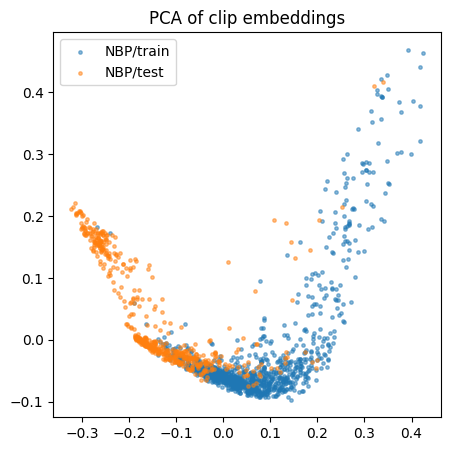

In [12]:
# Optional: quick 2D PCA visualization for one pair
try:
    import sklearn.decomposition as skd
    HAS_SK = True
except Exception:
    HAS_SK = False

if HAS_SK and len(PAIRS) > 0:
    a_subset, a_split, b_subset, b_split = PAIRS[0]
    xa = load_clip_embeddings(a_subset, a_split)
    xb = load_clip_embeddings(b_subset, b_split)
    xa = sample_embeddings(xa, 1000, RANDOM_SEED).numpy()
    xb = sample_embeddings(xb, 1000, RANDOM_SEED + 1).numpy()
    X = np.concatenate([xa, xb], axis=0)
    y = np.array([0] * xa.shape[0] + [1] * xb.shape[0])
    pca = skd.PCA(n_components=2)
    Z = pca.fit_transform(X)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,5))
    plt.scatter(Z[y==0,0], Z[y==0,1], s=6, alpha=0.5, label=f"{a_subset}/{a_split}")
    plt.scatter(Z[y==1,0], Z[y==1,1], s=6, alpha=0.5, label=f"{b_subset}/{b_split}")
    plt.legend()
    plt.title("PCA of clip embeddings")
    plt.show()
else:
    print("sklearn not available or no pairs configured; skipping PCA plot.")

## Class wise

Calculate metrics for each bird species class separately and then average the results.


In [13]:
# Compute class-wise shift metrics per pair (only for pairs within the same subset where label spaces match)
import pandas as pd

MIN_PER_CLASS = 20
MAX_PER_CLASS = 500
SEED_CLASS = 123
ENABLE_OT_CLASSWISE = False


def load_embeddings_and_labels(subset: str, split: str):
    p = latest_pickle_for(subset, split)
    if p is None:
        raise FileNotFoundError(f"No pickle found for {subset}/{split} under {OUTPUT_DIR}")
    with open(p, "rb") as f:
        data = pickle.load(f)
    emb = data["clip_embeddings"]
    if not isinstance(emb, torch.Tensor):
        emb = torch.as_tensor(emb)
    labels = data.get("labels", None)
    if labels is not None and not isinstance(labels, torch.Tensor):
        labels = torch.as_tensor(labels)
    return emb, labels


def per_class_metrics_for_pair(a_subset: str, a_split: str, b_subset: str, b_split: str,
                               min_per_class: int = MIN_PER_CLASS,
                               max_per_class: int = MAX_PER_CLASS,
                               seed: int = SEED_CLASS):
    embA, labA = load_embeddings_and_labels(a_subset, a_split)
    embB, labB = load_embeddings_and_labels(b_subset, b_split)

    if labA is None or labB is None:
        raise ValueError("Labels not found in embeddings bundles; re-run dump script with labels included.")
    if labA.shape[1] != labB.shape[1]:
        raise ValueError(f"Label dimension mismatch: {labA.shape[1]} vs {labB.shape[1]}. Class-wise comparison requires matching spaces.")

    # Ensure alignment: class spaces must be the same (works best for same subset across splits)
    num_classes = labA.shape[1]

    rng = torch.Generator().manual_seed(seed)

    rows = []
    for c in range(num_classes):
        idxA = (labA[:, c] > 0).nonzero(as_tuple=True)[0]
        idxB = (labB[:, c] > 0).nonzero(as_tuple=True)[0]
        nA = idxA.numel()
        nB = idxB.numel()
        if nA < min_per_class or nB < min_per_class:
            continue
        if nA > max_per_class:
            idxA = idxA[torch.randperm(nA, generator=rng)[:max_per_class]]
            nA = idxA.numel()
        if nB > max_per_class:
            idxB = idxB[torch.randperm(nB, generator=rng)[:max_per_class]]
            nB = idxB.numel()

        xa = embA[idxA].to(DEVICE).float()
        xb = embB[idxB].to(DEVICE).float()

        mmd = mmd_rbf(xa, xb)
        ed = energy_distance(xa, xb)
        try:
            fid = frechet_distance(xa, xb)
        except Exception:
            fid = float("nan")
        ot = None
        if ENABLE_OT_CLASSWISE:
            ot = sinkhorn_ot(xa, xb, eps=SINKHORN_EPS, iters=SINKHORN_ITERS)

        rows.append({
            "class_id": c,
            "N_A": int(nA),
            "N_B": int(nB),
            "MMD_RBF": mmd,
            "Energy": ed,
            "Frechet": fid,
            "SinkhornOT": ot,
        })

    df = pd.DataFrame(rows).sort_values(by="MMD_RBF", ascending=False, ignore_index=True)
    macro = {
        "class_id": "<macro>",
        "N_A": int(df["N_A"].sum()) if not df.empty else 0,
        "N_B": int(df["N_B"].sum()) if not df.empty else 0,
        "MMD_RBF": float(df["MMD_RBF"].mean()) if not df.empty else float("nan"),
        "Energy": float(df["Energy"].mean()) if not df.empty else float("nan"),
        "Frechet": float(df["Frechet"].mean()) if not df.empty else float("nan"),
        "SinkhornOT": float(df["SinkhornOT"].mean()) if (ENABLE_OT_CLASSWISE and not df["SinkhornOT"].isna().all()) else None,
    }
    return df, pd.Series(macro)


# Run for configured pairs and show summary + top classes by MMD
pair_summaries = []
per_pair_top = {}
for (a_subset, a_split, b_subset, b_split) in PAIRS:
    try:
        df_c, macro = per_class_metrics_for_pair(a_subset, a_split, b_subset, b_split)
    except Exception as e:
        print(f"Skipping {a_subset}/{a_split} vs {b_subset}/{b_split}: {e}")
        continue
    macro = macro.to_dict()
    macro.update({"A": f"{a_subset}/{a_split}", "B": f"{b_subset}/{b_split}", "classes_used": int(df_c.shape[0])})
    pair_summaries.append(macro)
    per_pair_top[f"{a_subset}/{a_split}__{b_subset}/{b_split}"] = df_c.head(10)

summary_df = pd.DataFrame(pair_summaries)
summary_df, per_pair_top

(  class_id    N_A    N_B   MMD_RBF    Energy   Frechet SinkhornOT          A  \
 0  <macro>  11500    608  0.308924  0.190246 -1.444982       None  NBP/train   
 1  <macro>   4893   3026  0.407506  0.209010 -1.449121       None  HSN/train   
 2  <macro>  21591   8347  0.172191  0.084166 -1.479287       None  NES/train   
 3  <macro>  17761   9612  0.307250  0.131706 -1.479627       None  SNE/train   
 4  <macro>  29080  19158  0.223980  0.095173 -1.484456       None  SSW/train   
 5  <macro>   6014   5437  0.148498  0.075142 -1.481350       None  UHH/train   
 
           B  classes_used  
 0  NBP/test            23  
 1  HSN/test            12  
 2  NES/test            54  
 3  SNE/test            36  
 4  SSW/test            59  
 5  UHH/test            18  ,
 {'NBP/train__NBP/test':    class_id  N_A  N_B   MMD_RBF    Energy   Frechet SinkhornOT
  0         1  500   33  0.509320  0.292451 -1.434704       None
  1         2  500   25  0.459860  0.298602 -1.421969       None
  2      